=== Credit Card Transaction Data ===
         amount  hour_of_day  is_weekend  distance_from_home  \
0   2346.340450           14           0           48.501531   
1  15050.607155           11           1           21.722169   
2   6583.728468           15           0           92.083492   
3   4564.712769           23           1           31.865492   
4    848.124352           18           0          193.412121   

   online_transaction  transaction_count_24h  is_fraud  
0                   0                      1         0  
1                   0                      9         0  
2                   1                     15         0  
3                   1                      1         0  
4                   1                     12         1  

Fraud Rate: 27.10%

=== RANDOM FOREST EVALUATION ===

--- Performance Metrics ---
Training Accuracy: 100.00%
Testing Accuracy: 96.00%

✅ Good Generalization (Bagging reduces variance)

--- Test Set Detailed Metrics ---
Precision: 0.979

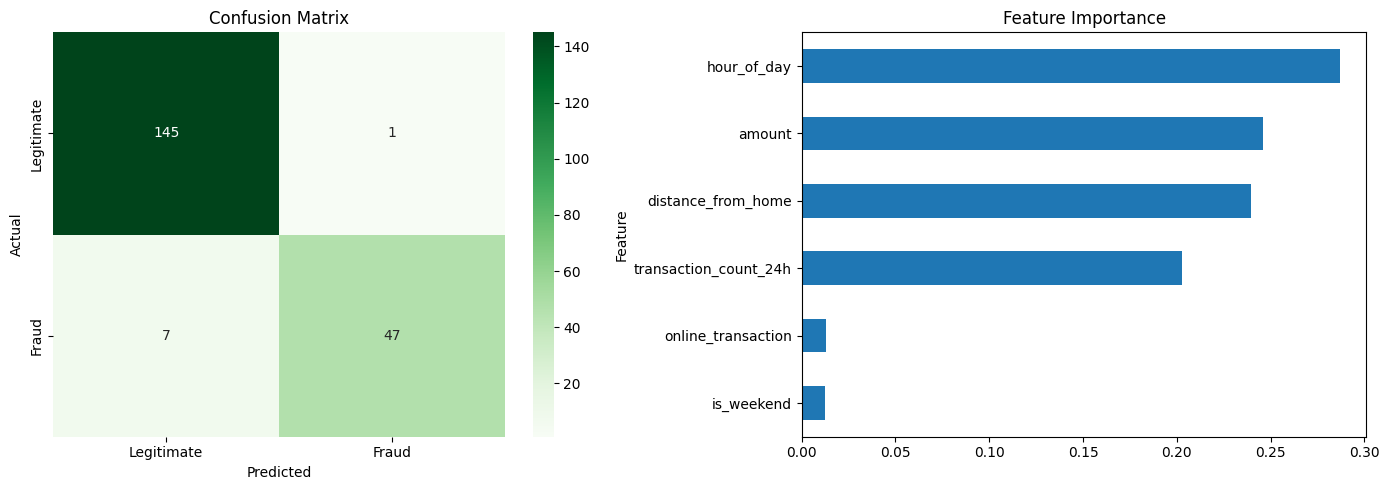

In [1]:
# ============================================================
# RANDOM FOREST - COMPLETE IMPLEMENTATION WITH EVALUATION
# ============================================================

# Step 1: Import Libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Create Dataset - Credit Card Fraud Detection
np.random.seed(42)
n_transactions = 1000

data = {
    'amount': np.random.exponential(5000, n_transactions),
    'hour_of_day': np.random.randint(0, 24, n_transactions),
    'is_weekend': np.random.choice([0, 1], n_transactions),
    'distance_from_home': np.random.exponential(50, n_transactions),
    'online_transaction': np.random.choice([0, 1], n_transactions),
    'transaction_count_24h': np.random.randint(1, 20, n_transactions),
}
df = pd.DataFrame(data)

# Fraud logic (unusual patterns)
fraud_score = (
    (df['amount'] > 10000).astype(int) +
    ((df['hour_of_day'] > 22) | (df['hour_of_day'] < 5)).astype(int) +
    (df['distance_from_home'] > 100).astype(int) +
    (df['transaction_count_24h'] > 10).astype(int)
)
df['is_fraud'] = (fraud_score >= 2).astype(int)

# Add noise
noise_idx = np.random.choice(n_transactions, size=int(n_transactions * 0.03), replace=False)
df.loc[noise_idx, 'is_fraud'] = 1 - df.loc[noise_idx, 'is_fraud']

print("=== Credit Card Transaction Data ===")
print(df.head())
print(f"\nFraud Rate: {df['is_fraud'].mean() * 100:.2f}%")

# Step 3: Prepare Data
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 4: Train Base Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Step 5: Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)
y_test_prob = rf_model.predict_proba(X_test)[:, 1]

# Step 6: EVALUATION
print(f"\n{'='*70}")
print("=== RANDOM FOREST EVALUATION ===")
print(f"{'='*70}")

print("\n--- Performance Metrics ---")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred) * 100:.2f}%")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred) * 100:.2f}%")

# Overfitting Check
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

if train_acc - test_acc > 0.1:
    print("\n⚠️ WARNING: Possible OVERFITTING")
else:
    print("\n✅ Good Generalization (Bagging reduces variance)")

# Detailed Metrics
print("\n--- Test Set Detailed Metrics ---")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_test_prob):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\n--- Confusion Matrix ---")
print(f"              Predicted")
print(f"            Legit   Fraud")
print(f"Actual Legit  {cm[0,0]:4d}    {cm[0,1]:4d}")
print(f"Actual Fraud  {cm[1,0]:4d}    {cm[1,1]:4d}")

# Step 7: FEATURE IMPORTANCE
print("\n--- Feature Importance (Random Forest) ---")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance.to_string(index=False))

# Step 8: CROSS-VALIDATION
print(f"\n{'='*70}")
print("=== CROSS-VALIDATION (5-Fold) ===")
print(f"{'='*70}")

cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1')
print(f"Fold F1 Scores: {np.round(cv_scores, 4)}")
print(f"Mean F1 Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Step 9: HYPERPARAMETER TUNING
print(f"\n{'='*70}")
print("=== HYPERPARAMETER TUNING ===")
print(f"{'='*70}")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

# Optimized Model
best_rf = grid_search.best_estimator_
y_best_pred = best_rf.predict(X_test)

print("\n--- Optimized Random Forest Performance ---")
print(f"Test Accuracy: {accuracy_score(y_test, y_best_pred) * 100:.2f}%")
print(f"Test F1 Score: {f1_score(y_test, y_best_pred):.4f}")

# Step 10: VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'],
            ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Feature Importance
feature_importance.sort_values('Importance').plot(
    kind='barh', x='Feature', y='Importance', ax=axes[1], legend=False
)
axes[1].set_title("Feature Importance")

plt.tight_layout()
plt.show()
